# 09. Pre-Game Draft Analysis


In [1]:
from pathlib import Path
import json
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = (
    Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

PREGAME_TRAIN_PATH = PROCESSED_DIR / "pregame_train_features.csv.gz"
PREGAME_VAL_PATH = PROCESSED_DIR / "pregame_val_features.csv.gz"
PREGAME_TEST_PATH = PROCESSED_DIR / "pregame_test_features.csv.gz"
PREGAME_SUMMARY_PATH = PROCESSED_DIR / "pregame_feature_engineering_summary.json"
PIPELINE_SUMMARY_PATH = PROCESSED_DIR / "pipeline_summary.json"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 1. Load Pre-Game Artifacts

This notebook expects the pre-game pipeline to have been run first.

In [2]:
missing_inputs = [
    path
    for path in [
        PREGAME_TRAIN_PATH,
        PREGAME_VAL_PATH,
        PREGAME_TEST_PATH,
        PREGAME_SUMMARY_PATH,
    ]
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        "Missing pre-game artifacts. Run `uv run python scripts/run_pipeline.py --scope pregame` first. Missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )

train_df = pd.read_csv(PREGAME_TRAIN_PATH)
val_df = pd.read_csv(PREGAME_VAL_PATH)
test_df = pd.read_csv(PREGAME_TEST_PATH)
pregame_summary = json.loads(PREGAME_SUMMARY_PATH.read_text(encoding="utf-8"))
pipeline_summary = (
    json.loads(PIPELINE_SUMMARY_PATH.read_text(encoding="utf-8"))
    if PIPELINE_SUMMARY_PATH.exists()
    else {}
)

print(f"Train rows: {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Selected feature count: {pregame_summary['feature_counts']['final_selected']}")

Train rows: 250,972
Validation rows: 35,854
Test rows: 71,708
Selected feature count: 7


## 2. Feature Scope and Split Summary

The pre-game pipeline intentionally uses compact, draft-safe signals rather than post-game combat or objective stats.

In [3]:
summary_rows = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "win_rate": train_df['win'].mean()},
        {"split": "val", "rows": len(val_df), "win_rate": val_df['win'].mean()},
        {"split": "test", "rows": len(test_df), "win_rate": test_df['win'].mean()},
    ]
)
display(summary_rows)

display(pd.DataFrame({"selected_feature": pregame_summary['selected_features']}))

,split,rows,win_rate
0,train,250972,0.5
1,val,35854,0.5
2,test,71708,0.5


,selected_feature
0,has_full_draft
1,is_blue_side
2,team_min_pick_rate
3,team_avg_champ_wr_diff_vs_opp
4,team_max_champ_wr_diff_vs_opp
5,team_avg_pick_rate_diff_vs_opp
6,draft_size


## 3. Core Pre-Game Feature Distributions

These plots show the main draft-time signals that survived preprocessing.

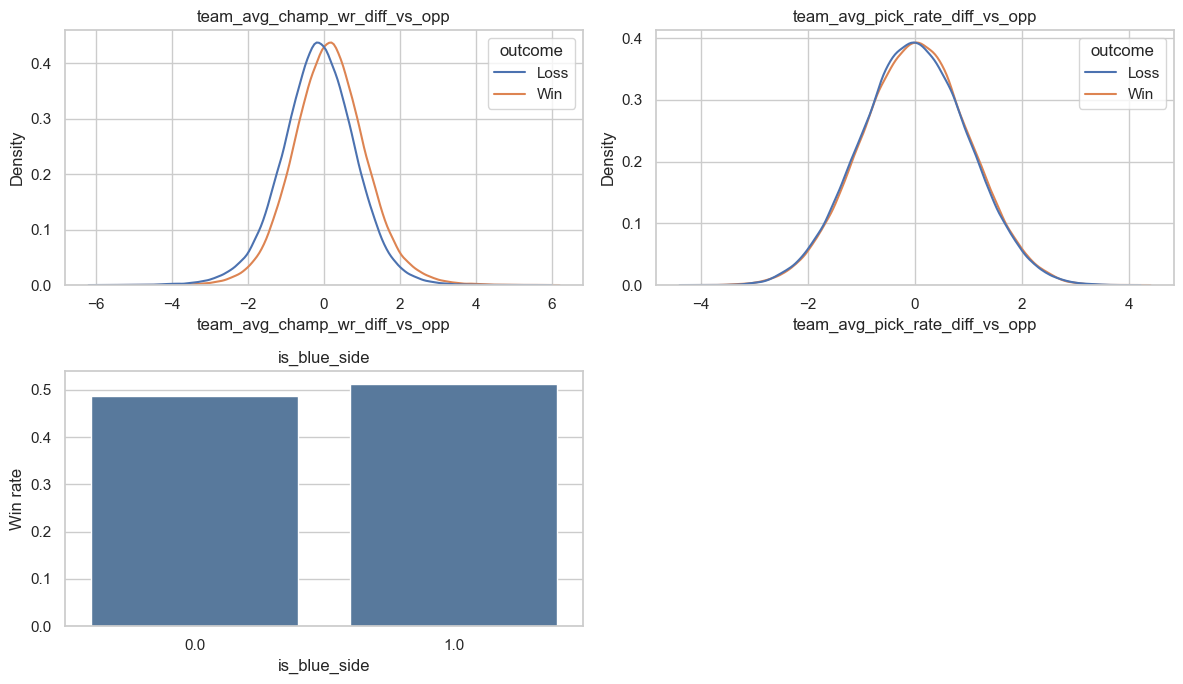

In [4]:
plot_columns = [
    column
    for column in [
        'team_avg_champ_wr',
        'team_avg_pick_rate',
        'team_avg_champ_wr_diff_vs_opp',
        'team_avg_pick_rate_diff_vs_opp',
        'is_blue_side',
        'n_bans',
    ]
    if column in train_df.columns
]

if not plot_columns:
    print('No expected pre-game columns were found in the engineered split.')
else:
    sample = train_df[plot_columns + ['win']].copy()
    sample['outcome'] = sample['win'].map({1: 'Win', 0: 'Loss'})

    ncols = 2
    nrows = (len(plot_columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(4, nrows * 3.5)))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for axis, column in zip(axes, plot_columns):
        if sample[column].nunique(dropna=False) <= 4:
            rate = sample.groupby(column, dropna=False)['win'].mean().reset_index()
            sns.barplot(data=rate, x=column, y='win', ax=axis, color='#4C78A8')
            axis.set_ylabel('Win rate')
        else:
            sns.kdeplot(data=sample, x=column, hue='outcome', common_norm=False, ax=axis)
            axis.set_ylabel('Density')
        axis.set_title(column)

    for axis in axes[len(plot_columns):]:
        axis.set_visible(False)

    plt.tight_layout()
    plt.show()

## 4. Latest Saved Pre-Game Training Runs

This section scans `models/03-pregame` for saved run artifacts and summarizes the latest results.

In [5]:
def collect_run_metrics(experiment_dir: Path) -> pd.DataFrame:
    rows = []
    for metrics_path in experiment_dir.glob('*/*/metrics.json'):
        metadata_path = metrics_path.parent / 'model_metadata.json'
        metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
        metadata = (
            json.loads(metadata_path.read_text(encoding='utf-8'))
            if metadata_path.exists()
            else {}
        )
        rows.append(
            {
                'model_name': metadata.get('model_name', metrics_path.parent.parent.name),
                'run_name': metadata.get('run_name', metrics_path.parent.name),
                'scope': metadata.get('scope', 'pregame'),
                'test_accuracy': metrics.get('test_accuracy'),
                'test_roc_auc': metrics.get('test_roc_auc'),
                'test_f1': metrics.get('test_f1'),
                'fit_seconds': metrics.get('fit_seconds'),
                'updated_at': metrics_path.stat().st_mtime,
            }
        )

    if not rows:
        return pd.DataFrame()

    frame = pd.DataFrame(rows).sort_values('updated_at', ascending=False)
    return frame.drop(columns=['updated_at']).reset_index(drop=True)

pregame_runs = collect_run_metrics(MODELS_DIR / '03-pregame')
if pregame_runs.empty:
    print('No pre-game training artifacts found yet. Run `uv run python scripts/run_training.py --scope pregame --experiment-name 03-pregame` first.')
else:
    display(pregame_runs)

,model_name,run_name,scope,test_accuracy,test_roc_auc,test_f1,fit_seconds
0,lightgbm,pregame-lightgbm,pregame,0.550692,0.569646,0.550685,1.198634


## 5. Pre-Game vs Post-Game Comparison

The useful question is not whether pre-game beats post-game. It should not. The point is to quantify the gap between a true prediction task and a post-game explanation task.

,scope,model_name,run_name,test_accuracy,test_roc_auc,test_f1,fit_seconds
0,pregame,lightgbm,pregame-lightgbm,0.550692,0.569646,0.550685,1.198634
1,postgame,lightgbm,lgbm-audit-ablated-objectives,0.976600,0.997813,0.976622,12.160318


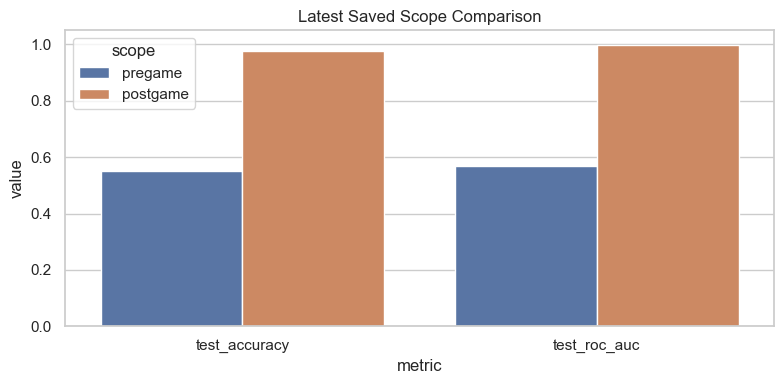

In [6]:
postgame_runs = collect_run_metrics(MODELS_DIR / '02-advanced-models')

comparison_rows = []
if not pregame_runs.empty:
    comparison_rows.append(pregame_runs.iloc[0].to_dict())
if not postgame_runs.empty:
    comparison_rows.append(postgame_runs.iloc[0].to_dict())

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    print('No saved model metrics were found for comparison yet.')
else:
    display(comparison_df[['scope', 'model_name', 'run_name', 'test_accuracy', 'test_roc_auc', 'test_f1', 'fit_seconds']])

    plot_df = comparison_df[['scope', 'test_accuracy', 'test_roc_auc']].melt(id_vars='scope', var_name='metric', value_name='value')
    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_df, x='metric', y='value', hue='scope')
    plt.ylim(0.0, 1.05)
    plt.title('Latest Saved Scope Comparison')
    plt.tight_layout()
    plt.show()

## 6. Takeaways

- Pre-game prediction is expected to be much weaker because draft alone captures only part of the eventual outcome.
- If performance is still materially above 50%, the draft priors are contributing real signal.
- The clean next step is to compare a simple baseline and a tree model on the same pre-game split, then inspect which draft-safe features remain most useful.